In [1]:
import pyBigWig
import pysam

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

In [2]:
def extract_bigwig_data(file_path):
    """
    Extract all intervals and values from a BigWig file.

    Args:
        file_path (str): Path to the BigWig file.

    Returns:
        dict: A dictionary where keys are chromosomes, and values are lists of tuples 
              (start, end, value) for each interval.
    """
    data = {}

    # Open the BigWig file
    with pyBigWig.open(file_path) as bw:
        # Get all chromosomes
        chromosomes = bw.chroms()
        
        # Iterate over chromosomes and extract intervals
        for chrom in chromosomes:

            intervals = bw.intervals(chrom)  # Fetch all intervals for the chromosome
            if intervals:
                data[chrom] = intervals  # Store as (start, end, value) tuples

    return data

def extract_bigwig_values(file_path):
    """
    Extract all intervals and values from a BigWig file.

    Args:
        file_path (str): Path to the BigWig file.

    Returns:
        dict: A dictionary where keys are chromosomes, and values are lists of tuples 
              (start, end, value) for each interval.
    """
    values = []

    # Open the BigWig file
    with pyBigWig.open(file_path) as bw:
        # Get all chromosomes
        chromosomes = bw.chroms()
        
        # Iterate over chromosomes and extract intervals
        for chrom in chromosomes:

            intervals = bw.intervals(chrom)  # Fetch all intervals for the chromosome
            for start, end, value in intervals:
                values.append(value)  # Store as (start, end, value) tuples

    return values


def get_seq_data(bigwig_data, chrom_list, threshold):
    seq_info = []
    for c, i in bigwig_data.items():
        if c in chrom_list:
            for start, end, value in i:
                if value > threshold:
                    seq_info.append([c, start, end, value])
                    
    return seq_info

In [3]:
# Define the encoding
BASE_ENCODING = {
    "A": [0, 0, 0, 1],
    "C": [0, 0, 1, 0],
    "G": [0, 1, 0, 0],
    "T": [1, 0, 0, 0],
    "N": [0, 0, 0, 0],  # Handle ambiguous bases
}

def encode_sequence(sequence):
    """Encodes a DNA sequence into binary format."""
    return np.array([BASE_ENCODING[base] for base in sequence])

def get_encoded_sequences_from_coordinates(reference_fasta, coordinates, max_length=150):
    """
    Fetches and encodes sequences for given coordinates.
    
    Args:
        reference_fasta (str): Path to the hg19 reference genome in FASTA format.
        coordinates (list): List of coordinates in 'chr:start-end' format.
    
    Returns:
        dict: Mapping of coordinates to encoded sequences.
    """
    # Open the reference genome
    fasta = pysam.FastaFile(reference_fasta)
    encoded_sequences = []
    y = []

    for i,coord in enumerate(coordinates):
        if i % 100000 == 0:
            print(i)
        chrom, start, end, y_ = coord
        # Fetch sequence
        seq = fasta.fetch(chrom, start, end).upper()
        diff = max_length - len(seq)
        seq = (math.floor(diff/2) * 'N') + seq + (math.ceil(diff/2) * 'N')
        y.append(y_)
        encoded_sequences.append(encode_sequence(seq))
    fasta.close()
    encoded_sequences = np.array(encoded_sequences)
    # encoded_sequences_reshaped = encoded_sequences.reshape((encoded_sequences.shape[0], encoded_sequences.shape[1], encoded_sequences.shape[2]))
    return encoded_sequences,np.array(y)


def get_encoded_sequences_from_coordinatesv2(bwfile, reference_fasta, coordinates,types='mean', n=200):
    """
    Fetches and encodes sequences for given coordinates.
    
    Args:
        reference_fasta (str): Path to the hg19 reference genome in FASTA format.
        coordinates (list): List of coordinates in 'chr:start-end' format.
    
    Returns:
        dict: Mapping of coordinates to encoded sequences.
    """
    # Open the reference genome
    fasta = pysam.FastaFile(reference_fasta)
    bw = pyBigWig.open(bwfile)
    encoded_sequences = []
    y = []

    for i,r in coordinates.iterrows():
        if i % 50000 == 0:
            print(i)
        coord = r['abs_summit']
        chrom = r['chr']
        
        start = coord - math.floor(n/2)
        end = coord + math.ceil(n/2)
        
        y_ = bw.stats(chrom, start, end, type=types)[0] or 0
        # Fetch sequence
        sequence = fasta.fetch(chrom, start, end).upper()
        if len(sequence) == n:
            y.append(y_)
            encoded_sequences.append(encode_sequence(sequence))
            
        s1 = start - n
        e1 = end - n        
        y_ = bw.stats(chrom, s1, e1, type=types)[0] or 0
        # Fetch sequence
        sequence = fasta.fetch(chrom, s1, e1).upper()
        if len(sequence) == n:
            y.append(y_)
            encoded_sequences.append(encode_sequence(sequence))
            
        # s11 = s1 - n
        # e11 = e1 - n        
        # y_ = bw.stats(chrom, s11, e11, type=types)[0] or 0
        # # Fetch sequence
        # sequence = fasta.fetch(chrom, s11, e11).upper()
        # if len(sequence) == n:
        #     y.append(y_)
        #     encoded_sequences.append(encode_sequence(sequence))
            
        s2 = start + n
        e2 = end + n        
        y_ = bw.stats(chrom, s2, e2, type=types)[0] or 0
        # Fetch sequence
        sequence = fasta.fetch(chrom, s2, e2).upper()
        if len(sequence) == n:
            y.append(y_)
            encoded_sequences.append(encode_sequence(sequence))
            
        # s22 = s2 + n
        # e22 = e2 + n        
        # y_ = bw.stats(chrom, s22, e22, type=types)[0] or 0
        # # Fetch sequence
        # sequence = fasta.fetch(chrom, s22, e22).upper()
        # if len(sequence) == n:
        #     if y_ != None:
        #         y.append(y_)
        #     else:
        #         y.append(0)
        #     encoded_sequences.append(encode_sequence(sequence))
        
        
    fasta.close()
    encoded_sequences = np.array(encoded_sequences)
    encoded_sequences = np.nan_to_num(encoded_sequences)
    y = np.array(y)
    y = np.nan_to_num(y)
    y = y.reshape(y.shape[0], -1)
    # encoded_sequences_reshaped = encoded_sequences.reshape((encoded_sequences.shape[0], encoded_sequences.shape[1], encoded_sequences.shape[2]))
    return encoded_sequences,y


In [4]:
bigwig_file = "./data/chip_seq_bw/rep3_log.bw"
peak_file = './data/Chip_seq/chip_peaks_3v2_peaks.xls'

hg19 = './data/hg19.fa'

In [5]:
shuffle_chs = ['chr1',
 'chr10',
 'chr11',
 'chr12',
 'chr13',
 'chr14',
 'chr15',
 'chr16',
 'chr17',
 'chr18',
 'chr19',
 'chr2',
 'chr20',
 'chr21',
 'chr22',
 'chr3',
 'chr4',
 'chr5',
 'chr6',
 'chr7',
 'chr8',
 'chr9',
 'chrX',
 'chrY'
]
random.shuffle(shuffle_chs)
n_train, n_test, n_val = 16, 5, 3
                              
ch_train, ch_test, ch_val = shuffle_chs[:n_train], shuffle_chs[n_train:n_train+n_test], shuffle_chs[-n_val:]

In [6]:
df = pd.read_csv(peak_file, sep='\t', comment='#')

df_train = df[df['chr'].isin(ch_train)]
coor_train = df_train[['abs_summit','chr']]

df_test = df[df['chr'].isin(ch_test)]
coor_test = df_test[['abs_summit','chr']]

df_val = df[df['chr'].isin(ch_val)]
coor_val = df_val[['abs_summit','chr']]

In [7]:
seqsize = 250
X_train, y_train = get_encoded_sequences_from_coordinatesv2(bigwig_file, hg19, coor_train, n=seqsize)
print(X_train.shape, y_train.shape)

0
50000
(138924, 250, 4) (138924, 1)


In [8]:
X_test, y_test = get_encoded_sequences_from_coordinatesv2(bigwig_file, hg19, coor_test, n=seqsize)
print(X_test.shape, y_test.shape)

(36081, 250, 4) (36081, 1)


In [9]:
X_val, y_val = get_encoded_sequences_from_coordinatesv2(bigwig_file, hg19, coor_val, n=seqsize)
print(X_val.shape, y_val.shape)

(20544, 250, 4) (20544, 1)


In [10]:
# from sklearn.preprocessing import StandardScaler
# y_scaler = StandardScaler()
# y_train = y_scaler.fit_transform(y_train)
# y_test = y_scaler.transform(y_test)
# y_val = y_scaler.transform(y_val)

(array([   4.,    7.,   28.,   54.,   64.,   99.,  155.,  255.,  386.,
         548.,  763.,  996., 1325., 1585., 1869., 2090., 2077., 2005.,
        1804., 1858., 1987., 2047., 2032., 1741., 1469., 1229., 1084.,
         935.,  826.,  706.,  585.,  482.,  458.,  381.,  335.,  296.,
         257.,  206.,  180.,  188.,  170.,  143.,  115.,   94.,   55.,
          51.,   28.,   16.,    6.,    7.]),
 array([-1.65636381e+00, -1.51823896e+00, -1.38011411e+00, -1.24198926e+00,
        -1.10386440e+00, -9.65739553e-01, -8.27614702e-01, -6.89489850e-01,
        -5.51364999e-01, -4.13240148e-01, -2.75115297e-01, -1.36990445e-01,
         1.13440596e-03,  1.39259257e-01,  2.77384108e-01,  4.15508960e-01,
         5.53633811e-01,  6.91758662e-01,  8.29883513e-01,  9.68008365e-01,
         1.10613322e+00,  1.24425807e+00,  1.38238292e+00,  1.52050777e+00,
         1.65863262e+00,  1.79675747e+00,  1.93488232e+00,  2.07300717e+00,
         2.21113203e+00,  2.34925688e+00,  2.48738173e+00,  2.625506

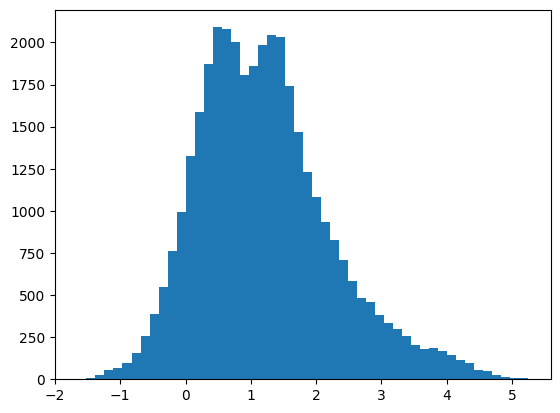

In [11]:
plt.hist(y_test, bins=50)

(array([4.000e+00, 5.000e+00, 1.900e+01, 4.000e+01, 6.500e+01, 1.420e+02,
        2.070e+02, 3.940e+02, 6.910e+02, 1.103e+03, 1.692e+03, 2.605e+03,
        3.643e+03, 5.067e+03, 6.416e+03, 7.665e+03, 8.434e+03, 8.762e+03,
        8.396e+03, 7.967e+03, 7.794e+03, 8.180e+03, 8.528e+03, 8.054e+03,
        6.687e+03, 5.540e+03, 4.669e+03, 3.990e+03, 3.510e+03, 2.936e+03,
        2.430e+03, 2.058e+03, 1.784e+03, 1.562e+03, 1.301e+03, 1.099e+03,
        1.011e+03, 8.900e+02, 7.640e+02, 7.090e+02, 5.830e+02, 4.900e+02,
        3.960e+02, 2.730e+02, 1.780e+02, 9.700e+01, 5.400e+01, 2.700e+01,
        7.000e+00, 6.000e+00]),
 array([-2.00663651, -1.85741251, -1.70818851, -1.55896451, -1.40974052,
        -1.26051652, -1.11129252, -0.96206852, -0.81284452, -0.66362053,
        -0.51439653, -0.36517253, -0.21594853, -0.06672454,  0.08249946,
         0.23172346,  0.38094746,  0.53017146,  0.67939545,  0.82861945,
         0.97784345,  1.12706745,  1.27629144,  1.42551544,  1.57473944,
         1.

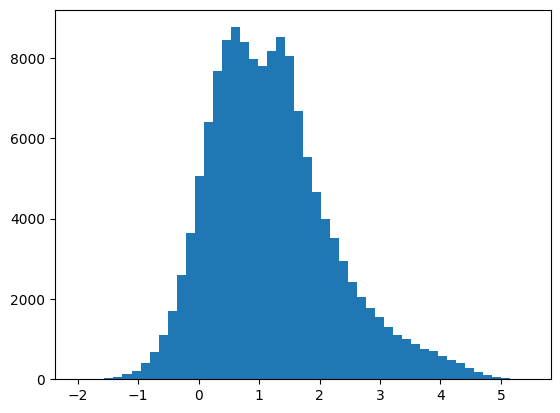

In [12]:
plt.hist(y_train, bins=50)

(array([5.000e+00, 1.200e+01, 1.200e+01, 2.600e+01, 3.800e+01, 6.400e+01,
        1.180e+02, 2.430e+02, 3.260e+02, 4.660e+02, 6.920e+02, 9.480e+02,
        1.160e+03, 1.302e+03, 1.356e+03, 1.247e+03, 1.165e+03, 1.130e+03,
        1.265e+03, 1.224e+03, 1.162e+03, 1.030e+03, 9.080e+02, 7.310e+02,
        6.240e+02, 5.160e+02, 4.290e+02, 3.660e+02, 3.160e+02, 2.510e+02,
        2.390e+02, 1.760e+02, 1.770e+02, 1.690e+02, 1.500e+02, 1.140e+02,
        1.030e+02, 8.600e+01, 5.800e+01, 4.300e+01, 2.700e+01, 2.800e+01,
        1.300e+01, 8.000e+00, 9.000e+00, 9.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00]),
 array([-1.6731764 , -1.52202428, -1.37087216, -1.21972004, -1.06856793,
        -0.91741581, -0.76626369, -0.61511157, -0.46395945, -0.31280733,
        -0.16165522, -0.0105031 ,  0.14064902,  0.29180114,  0.44295326,
         0.59410538,  0.74525749,  0.89640961,  1.04756173,  1.19871385,
         1.34986597,  1.50101809,  1.6521702 ,  1.80332232,  1.95447444,
         2.

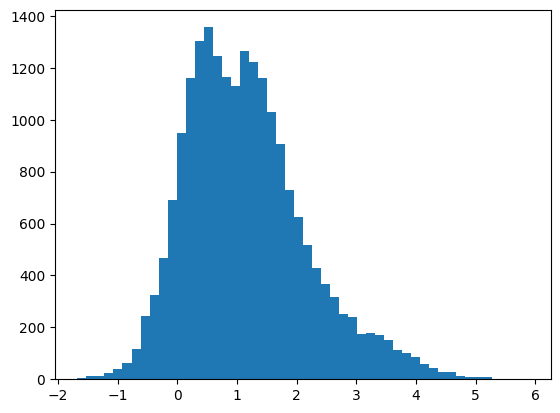

In [13]:
plt.hist(y_val, bins=50)

In [14]:
from scipy.stats import spearmanr
def Spearman(y_true, y_pred):
     return ( tf.py_function(spearmanr, [tf.cast(y_pred, tf.float32), 
                       tf.cast(y_true, tf.float32)], Tout = tf.float32) )

In [15]:
import tensorflow as tf

import keras
import keras.layers as kl
# from keras.layers.convolutional import Conv1D, MaxPooling1D, AveragePooling1D
from keras.layers import Dropout, Reshape, Dense, Activation, Flatten,Conv1D, MaxPooling1D, AveragePooling1D
from keras.layers import BatchNormalization, InputLayer, Input, LeakyReLU, PReLU, ELU
from keras import models
from keras.models import Sequential, Model
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, History, ModelCheckpoint

2026-03-24 10:34:14.809695: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 10:34:14.873644: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-24 10:34:14.873697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-24 10:34:14.875052: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-24 10:34:14.883276: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
params = {'batch_size': 256,
          'epochs': 50,
          'early_stop': 10,
          'kernel_size1': 7,
          'kernel_size2': 7,
          'kernel_size3': 5,
          'kernel_size4': 5,
          'kernel_size5': 3,

          'lr': 0.001,
          'num_filters': 256,
          'num_filters2': 128,
          'num_filters3': 64,
          'num_filters4': 64,
          'num_filters5': 32,

          'n_conv_layer': 5,
          'n_add_layer': 2,
          'dropout_prob': 0.2,
          'dense_neurons1': 256,
          'dense_neurons2': 256,
          'pad':'same',
          'seqsize': seqsize
         }

def DeepSTARR(params=params):
    
    lr = params['lr']
    dropout_prob = params['dropout_prob']
    n_conv_layer = params['n_conv_layer']
    n_add_layer = params['n_add_layer']
    seqsize  = params['seqsize']
    # body
    input = kl.Input(shape=(seqsize, 4))
    x = kl.Conv1D(params['num_filters'], kernel_size=params['kernel_size1'],
                  padding=params['pad'],
                  name='Conv1D_1st')(input)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.01)(x)
    x = AveragePooling1D(2)(x)

    for i in range(1, n_conv_layer):
        x = kl.Conv1D(params['num_filters'+str(i+1)],
                      kernel_size=params['kernel_size'+str(i+1)],
                      padding=params['pad'],
                      name=str('Conv1D_'+str(i+1)))(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha=0.01)(x)
        x = AveragePooling1D(2)(x)
    
    x = Flatten()(x)
    
    # dense layers
    for i in range(0, n_add_layer):
        x = kl.Dense(params['dense_neurons'+str(i+1)],
                     name=str('Dense_'+str(i+1)))(x)
        x = BatchNormalization()(x)
        x = LeakyReLU(alpha=0.01)(x)
        x = Dropout(dropout_prob)(x)
    
    outputs = kl.Dense(1, activation='linear', name='Dense_final', bias_initializer='zeros')(x)

    model = keras.models.Model([input], outputs)
    model.compile(keras.optimizers.Adam(learning_rate=lr),
                  loss='mse')
    return model, params

DeepSTARR()[0].summary()

2026-03-24 10:34:38.934026: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 250, 4)]          0         
                                                                 
 Conv1D_1st (Conv1D)         (None, 250, 256)          7424      
                                                                 
 batch_normalization (Batch  (None, 250, 256)          1024      
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 250, 256)          0         
                                                                 
 average_pooling1d (Average  (None, 125, 256)          0         
 Pooling1D)                                                      
                                                                 
 Conv1D_2 (Conv1D)           (None, 125, 128)          229504

In [17]:
main_model, params = DeepSTARR()
my_history=main_model.fit(X_train, y_train,                              
                          validation_data=(X_val, y_val),
                          batch_size=params['batch_size'], epochs=params['epochs'],
                          callbacks=[EarlyStopping(patience=params['early_stop'], monitor="val_loss", restore_best_weights=True)])

Epoch 1/50
543/543 [==============================] - 576s 1s/step - loss: 0.9258 - val_loss: 0.7152
Epoch 2/50
543/543 [==============================] - 572s 1s/step - loss: 0.6610 - val_loss: 0.6922
Epoch 3/50
543/543 [==============================] - 594s 1s/step - loss: 0.6300 - val_loss: 0.6469
Epoch 4/50
543/543 [==============================] - 582s 1s/step - loss: 0.6110 - val_loss: 0.6785
Epoch 5/50
543/543 [==============================] - 593s 1s/step - loss: 0.5958 - val_loss: 0.6442
Epoch 6/50
543/543 [==============================] - 568s 1s/step - loss: 0.5823 - val_loss: 0.6076
Epoch 7/50
543/543 [==============================] - 586s 1s/step - loss: 0.5679 - val_loss: 0.5966
Epoch 8/50
543/543 [==============================] - 578s 1s/step - loss: 0.5579 - val_loss: 0.6426
Epoch 9/50
543/543 [==============================] - 577s 1s/step - loss: 0.5449 - val_loss: 0.7132
Epoch 10/50
543/543 [==============================] - 577s 1s/step - loss: 0.5300 - val_lo

In [18]:
y_pred = main_model.predict(X_test)

1128/1128 [==============================] - 30s 24ms/step


In [19]:
print("Min Prediction:", y_pred.min())  
print("Max Prediction:", y_pred.max())  
print("Mean Prediction:", y_pred.mean())  

Min Prediction: 0.38097644
Max Prediction: 5.382553
Mean Prediction: 1.2076278


In [20]:
from scipy.stats import spearmanr
print('r=: ', spearmanr(y_test, y_pred))

r=:  SignificanceResult(statistic=0.5875504913579893, pvalue=0.0)


In [21]:
from scipy.stats import pearsonr
print('r=: ', pearsonr(y_test.reshape(y_test.shape[0]), y_pred.reshape(y_pred.shape[0])))

r=:  PearsonRResult(statistic=0.6608832824585796, pvalue=0.0)


In [22]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_grey", ["#B3B3B3", "#4D4D4D"])

In [23]:
y_test = y_test.reshape(y_test.shape[0])
y_pred = y_pred.reshape(y_pred.shape[0])

df = pd.DataFrame({'y_pred':y_pred, 'y_test': y_test})
df.to_csv('occupancy_pred_test.csv', index=None)

In [24]:
from scipy.stats import gaussian_kde, linregress
xy = np.vstack([y_test, y_pred])
xy = np.nan_to_num(xy)
z = gaussian_kde(xy)(xy)

# Sort the points by density (optional, for better visualization)
idx = z.argsort()
y_test, y_pred, z = y_test[idx], y_pred[idx], z[idx]
r, _ = pearsonr(y_test, y_pred)

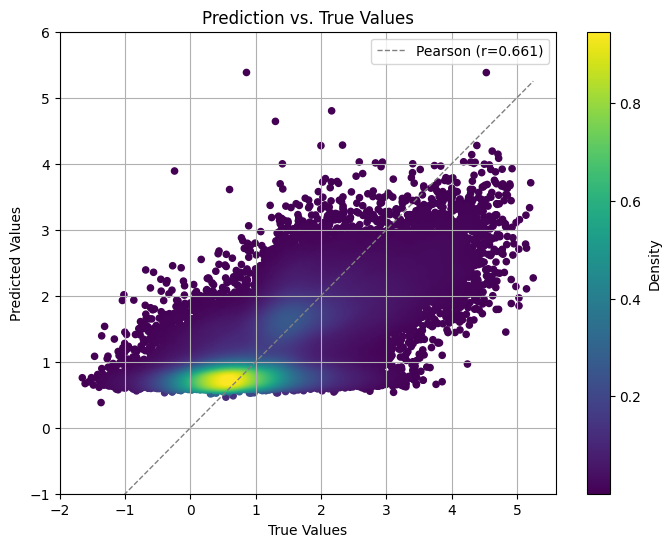

In [25]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    y_test,
    y_pred,
    c=z,
    cmap='viridis',   # or 'plasma', 'inferno', etc.
    s=20,
    edgecolor=None
)

x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, x_line, linestyle='dashed', color='grey', linewidth=1,  label=f'Pearson (r={r:.3f})')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
# plt.xlim([-1,5])
plt.ylim([-1,6])
plt.colorbar(sc, label='Density')
plt.title('Prediction vs. True Values')
plt.legend()
plt.grid(True)
plt.savefig('Chip_seq_cnn.pdf')

In [ ]:
#####################################

In [28]:
main_model.save_weights('Model_best_used.h5')

In [29]:
df = pd.read_csv('./data/GATA1_oligo_synthesis_info.csv')
df = df[['type', 'oligo_seq_230nt']]
df_o = df[df['type'] == 'original']
df_m = df[df['type'] == 'modified']

In [30]:
df_o.shape, df_m.shape

((2598, 2), (2582, 2))

In [31]:
def encode_seq(seq_list, n=250):
    encoded_sequences = []
    for seq in seq_list:
        seq = seq.upper()
        diff = n - len(seq)
        seq = (math.floor(diff/2) * 'N') + seq + (math.ceil(diff/2) * 'N')
        encoded_sequences.append(encode_sequence(seq))
    encoded_sequences = np.array(encoded_sequences)
    encoded_sequences = np.nan_to_num(encoded_sequences)
    return encoded_sequences

In [32]:
seq_o = list(df_o['oligo_seq_230nt'])
seq_m = list(df_m['oligo_seq_230nt'])

X_o = encode_seq(seq_o)
X_m = encode_seq(seq_m)

In [33]:
y_o = main_model.predict(X_o)
y_m = main_model.predict(X_m)

81/81 [==============================] - 1s 7ms/step


([<matplotlib.axis.XTick at 0x1549774b8b80>,
 [Text(0, 0, 'original'), Text(1, 0, 'modified')])

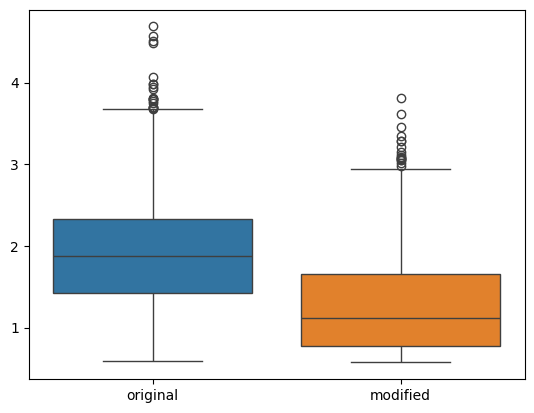

In [34]:
y_o = y_o.reshape(y_o.shape[0])
y_m = y_m.reshape(y_m.shape[0])

sns.boxplot([y_o, y_m])
plt.xticks([0,1],['original', 'modified'])

In [35]:
df = pd.read_csv('./data/GATA1_oligo_synthesis_info.csv')
df = df[['WGATAR_id', 'type', 'oligo_seq_230nt']]

In [36]:
g = df.groupby('WGATAR_id')

ids = []
seq_o = []
seq_m = []

for i in g.groups.keys():
    t = g.get_group(i)
    if len(t) == 2:
        ids.append(i)
        seq_o.append(list(t.loc[t['type'] == 'original', 'oligo_seq_230nt'])[0])
        seq_m.append(list(t.loc[t['type'] == 'modified', 'oligo_seq_230nt'])[0])

In [37]:
len(ids), len(seq_o), len(seq_m)

(2582, 2582, 2582)

In [38]:
X_o = encode_seq(seq_o)
X_m = encode_seq(seq_m)

In [39]:
y_o = main_model.predict(X_o)
y_m = main_model.predict(X_m)

81/81 [==============================] - 1s 7ms/step


In [40]:
y_o = y_o.reshape(y_o.shape[0])
y_m = y_m.reshape(y_m.shape[0])

delta = y_o - y_m

In [41]:
d = pd.DataFrame({'id':ids, 'delta_occupancy': delta})

In [ ]:
# d.to_pickle(''./data/delta_occupancy.pkl')